# Notebook 03 — Feature Engineering

**Projeto:** FSQA Take-Home Case — Modelagem Preditiva de Default em CRE  
**Fase:** 3 de 4  
**Dependência:** `../data/processed/df_clean.csv` (output do Notebook 01)

---

## Objetivos desta Fase

Transformar as variáveis brutas em **features otimizadas para o modelo**, capturando relações econômicas que variáveis isoladas não capturam:

1. **Features financeiras derivadas** — LTV, DSCR, Loan Age, Amortization Rate, NOI Yield
2. **Features de risco de refinanciamento** — Near_Maturity_Flag, Balloon_Risk
3. **Encoding de variáveis categóricas** — One-Hot, Label e Ordinal Encoding
4. **Tratamento de valores ausentes** — Property Class para não-Office
5. **Winsorizing de outliers** — LTV e DSCR nos percentis 1%-99%

**Output desta fase:** `df_features` salvo em `../data/processed/df_features.csv` — pronto para a modelagem.

---
## 1. Imports e Configuração

In [23]:
# =============================================================================
# Imports
# =============================================================================
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.4f}'.format)

# =============================================================================
# Caminhos
# =============================================================================
CLEAN_DATA_PATH    = '../data/processed/df_clean.csv'
FEATURES_DATA_PATH = '../data/processed/df_features.csv'
OUTPUT_DIR         = '../outputs/features/'

os.makedirs(OUTPUT_DIR, exist_ok=True)

print('Ambiente configurado.')

Ambiente configurado.


---
## 2. Carregamento dos Dados

In [24]:
# =============================================================================
# Carregar df_clean da Fase 1
# =============================================================================

df = pd.read_csv(
    CLEAN_DATA_PATH,
    encoding='utf-8',
    parse_dates=['Rating snapshot date']
)

# Reforçar tipos para evitar problemas downstream
cat_cols = ['Property type', 'Principal Repayment Type', 'Region', 'Property Class']
for col in cat_cols:
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].replace('nan', np.nan)

print(f'Shape: {df.shape}')
print(f'Colunas: {list(df.columns)}')
df.head(3)

Shape: (8959, 15)
Colunas: ['Facility ID', 'Property type', 'Rating snapshot date', 'Original Loan Amount', 'Principal Repayment Type', 'Current Loan Balance', 'Interest rate', 'Property value', 'Net operating income', 'Contractual term', 'Months to maturity', 'Annual tenant turnover', 'Region', 'Property Class', 'Default flag']


,Facility ID,Property type,Rating snapshot date,Original Loan Amount,Principal Repayment Type,Current Loan Balance,Interest rate,Property value,Net operating income,Contractual term,Months to maturity,Annual tenant turnover,Region,Property Class,Default flag
0,ABC1000001,Office building,2020-01-01,1460057.0600,Fully amortizing,1460057.0600,0.0766,2212207.6600,185161.7800,120,120,0.3900,West,Class B,0
1,ABC1000002,Multifamily residential,2017-01-01,771057.5200,Partially amortizing,583433.5300,0.0757,1041969.6200,49493.5600,120,47,0.3900,Northeast,NaN,0
2,ABC1000003,Retail space,2021-01-01,611478.9300,Fully amortizing,66243.5500,0.0774,899233.7200,70679.7700,120,13,0.2100,Northeast,NaN,0


---
## 3. Feature Engineering — Classe Principal

Seguindo o princípio de **Open/Closed** (SOLID), todas as transformações são encapsuladas em uma classe `CREFeatureEngineer`. Isso facilita reuso, teste e extensão sem modificar o código existente.

In [25]:
# =============================================================================
# Classe CREFeatureEngineer
# Encapsula todas as transformações de feature engineering.
# Cada método é responsável por uma categoria de feature (SRP).
# O método transform() orquestra a sequência completa.
# =============================================================================

class CREFeatureEngineer:
    """
    Engenharia de features para dataset de empréstimos CRE.

    Responsabilidades:
        - Derivar features financeiras (LTV, DSCR, NOI Yield, etc.)
        - Criar flags de risco de refinanciamento
        - Codificar variáveis categóricas
        - Aplicar winsorizing em outliers
        - Remover colunas não utilizadas no modelo

    Uso:
        engineer = CREFeatureEngineer()
        df_features = engineer.transform(df_clean)
    """

    # Limiares de risco de refinanciamento (em meses)
    NEAR_MATURITY_THRESHOLD  = 12
    BALLOON_RISK_THRESHOLD   = 24

    # Percentis para winsorizing
    WINSOR_LOW  = 0.01
    WINSOR_HIGH = 0.99

    # Mapeamento ordinal: Property Class
    PROPERTY_CLASS_MAP = {
        np.nan:     0,
        'Class C':  1,
        'Class B':  2,
        'Class A':  3,
    }

    def __init__(self):
        self._winsor_bounds: dict = {}  # Armazena limites de winsorizing para reprodutibilidade

    # -------------------------------------------------------------------------
    # 3.1 Features Financeiras Derivadas
    # -------------------------------------------------------------------------

    def _add_ltv(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Loan-to-Value (LTV) = Current Loan Balance / Property Value.

        Interpretação: alavancagem do empréstimo.
        LTV > 1: saldo devedor supera o valor do imóvel — perda garantida em execução.
        Hipótese: coeficiente POSITIVO no modelo (maior LTV → maior risco).
        """
        df['ltv'] = df['Current Loan Balance'] / df['Property value'].replace(0, np.nan)
        return df

    def _add_debt_service(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Debt Service Anual Estimado = Current Loan Balance × Interest Rate.

        Aproximação do custo anual do serviço da dívida.
        Usado como denominador do DSCR.
        """
        df['debt_service_annual'] = df['Current Loan Balance'] * df['Interest rate']
        return df

    def _add_dscr(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Debt Service Coverage Ratio (DSCR) = NOI / Debt Service Anual.

        Interpretação: número de vezes que o NOI cobre os juros anuais.
        DSCR < 1: imóvel não gera renda suficiente para cobrir o serviço da dívida.
        Hipótese: coeficiente NEGATIVO no modelo (maior DSCR → menor risco).
        """
        df['dscr'] = df['Net operating income'] / df['debt_service_annual'].replace(0, np.nan)
        return df

    def _add_loan_age(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Loan Age (meses) = Contractual Term - Months to Maturity.

        Tempo de vida do empréstimo desde a originação até o snapshot.
        Loans recentes têm menos histórico de pagamento; loans maduros têm track record.
        """
        df['loan_age_months'] = df['Contractual term'] - df['Months to maturity']
        df['loan_age_months'] = df['loan_age_months'].clip(lower=0)
        return df

    def _add_amortization_rate(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Amortization Rate = 1 - (Current Balance / Original Loan Amount).

        Proporção do principal já pago. Valores negativos (se Balance > Original)
        são clipados em 0. Valores > 1 são clipados em 1.
        """
        ratio = df['Current Loan Balance'] / df['Original Loan Amount'].replace(0, np.nan)
        df['amortization_rate'] = (1 - ratio).clip(0, 1)
        return df

    def _add_noi_yield(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        NOI Yield on Value = Net Operating Income / Property Value.

        Análogo ao cap rate do imóvel. Imóveis com NOI Yield baixo podem estar
        superavaliados ou com alta vacância.
        """
        df['noi_yield'] = df['Net operating income'] / df['Property value'].replace(0, np.nan)
        return df

    # -------------------------------------------------------------------------
    # 3.2 Features de Risco de Refinanciamento
    # -------------------------------------------------------------------------

    def _add_refinancing_risk_flags(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Cria flags binários de risco de refinanciamento:

        near_maturity_flag: 1 se Months to Maturity <= 12.
            Loans prestes a vencer podem não conseguir refinanciar.

        balloon_risk: 1 se Partially Amortizing E Months to Maturity <= 24.
            Combinação de balloon payment iminente com proximidade do vencimento —
            risco máximo de refinanciamento.
        """
        is_partial = df['Principal Repayment Type'] == 'Partially amortizing'
        is_near    = df['Months to maturity'] <= self.NEAR_MATURITY_THRESHOLD
        is_balloon = df['Months to maturity'] <= self.BALLOON_RISK_THRESHOLD

        df['near_maturity_flag'] = is_near.astype(int)
        df['balloon_risk']       = (is_partial & is_balloon).astype(int)
        return df

    # -------------------------------------------------------------------------
    # 3.3 Encoding de Variáveis Categóricas
    # -------------------------------------------------------------------------

    def _encode_repayment_type(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Principal Repayment Type: Label Encoding binário.
            0 = Fully amortizing
            1 = Partially amortizing
        """
        df['is_partially_amortizing'] = (
            df['Principal Repayment Type'] == 'Partially amortizing'
        ).astype(int)
        return df

    def _encode_property_class(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Property Class: Ordinal Encoding + indicador de não-Office.

        Mapeamento:
            NaN (non-Office) → 0
            Class C          → 1
            Class B          → 2
            Class A          → 3

        Cria também 'is_office' para indicar se o imóvel é Office Building.
        """
        df['is_office']         = (df['Property type'] == 'Office building').astype(int)
        df['property_class_ord'] = df['Property Class'].map(self.PROPERTY_CLASS_MAP).fillna(0).astype(int)
        return df

    def _encode_one_hot(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        One-Hot Encoding para variáveis nominais:
            - Property type (3 categorias → 2 dummies com drop_first)
            - Region (4 categorias → 3 dummies com drop_first)

        drop_first=True evita multicolinearidade perfeita (dummy trap).
        """
        df = pd.get_dummies(
            df,
            columns=['Property type', 'Region'],
            drop_first=True,
            dtype=int
        )
        # Normalizar nomes de colunas: espaços → underscores, minúsculas
        df.columns = [
            c.lower().replace(' ', '_').replace('-', '_')
            for c in df.columns
        ]
        return df

    # -------------------------------------------------------------------------
    # 3.4 Winsorizing
    # -------------------------------------------------------------------------

    def _winsorize(self, df: pd.DataFrame, cols: list) -> pd.DataFrame:
        """
        Aplica winsorizing nas colunas especificadas.
        Substitui valores abaixo do percentil 1% e acima do percentil 99%
        pelos respectivos limites.

        Armazena os limites em self._winsor_bounds para eventual aplicação
        em dados de produção.

        Args:
            df: DataFrame
            cols: lista de colunas numéricas a winsorizar

        Returns:
            DataFrame com outliers extremos clipados
        """
        for col in cols:
            lo = df[col].quantile(self.WINSOR_LOW)
            hi = df[col].quantile(self.WINSOR_HIGH)
            self._winsor_bounds[col] = (lo, hi)
            df[col] = df[col].clip(lo, hi)
            print(f'  Winsorizing {col}: [{lo:.4f}, {hi:.4f}]')
        return df

    # -------------------------------------------------------------------------
    # 3.5 Remoção de Colunas
    # -------------------------------------------------------------------------

    def _drop_unused_columns(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Remove colunas que não serão utilizadas no modelo:
            - facility_id: identificador sem poder preditivo
            - rating_snapshot_date: informação temporal já capturada indiretamente
            - original_loan_amount: substituída por amortization_rate e ltv
            - current_loan_balance: componente do LTV e DSCR
            - property_value: componente do LTV e NOI Yield
            - net_operating_income: componente do DSCR e NOI Yield
            - principal_repayment_type: substituída por is_partially_amortizing
            - property_class: substituída por property_class_ord
            - debt_service_annual: coluna intermediária (insumo para DSCR)
        """
        cols_to_drop = [
            'facility_id',
            'rating_snapshot_date',
            'original_loan_amount',
            'current_loan_balance',
            'property_value',
            'net_operating_income',
            'principal_repayment_type',
            'property_class',
            'debt_service_annual',
        ]
        existing = [c for c in cols_to_drop if c in df.columns]
        return df.drop(columns=existing)

    # -------------------------------------------------------------------------
    # 3.6 Método Principal: transform()
    # -------------------------------------------------------------------------

    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Orquestra a sequência completa de feature engineering.

        Ordem de execução:
            1. Encoding de categorias (antes do OHE, para ter colunas originais)
            2. Features financeiras derivadas
            3. Features de risco de refinanciamento
            4. One-Hot Encoding (renomeia colunas)
            5. Winsorizing de outliers
            6. Remoção de colunas não utilizadas

        Args:
            df: DataFrame limpo (output do ETL)

        Returns:
            DataFrame com todas as features prontas para modelagem
        """
        result = df.copy()

        print('Iniciando Feature Engineering...')

        # 1. Encoding de categorias (usa colunas originais)
        print('  [1/6] Encoding de variáveis categóricas...')
        result = self._encode_repayment_type(result)
        result = self._encode_property_class(result)

        # 2. Features financeiras
        print('  [2/6] Derivando features financeiras...')
        result = self._add_ltv(result)
        result = self._add_debt_service(result)
        result = self._add_dscr(result)
        result = self._add_loan_age(result)
        result = self._add_amortization_rate(result)
        result = self._add_noi_yield(result)

        # 3. Flags de risco de refinanciamento
        print('  [3/6] Criando flags de risco de refinanciamento...')
        result = self._add_refinancing_risk_flags(result)

        # 4. One-Hot Encoding (renomeia colunas para lowercase_underscore)
        print('  [4/6] One-Hot Encoding (Property type, Region)...')
        result = self._encode_one_hot(result)

        # 5. Winsorizing
        print('  [5/6] Winsorizing de outliers...')
        winsor_cols = ['ltv', 'dscr', 'noi_yield']
        result = self._winsorize(result, winsor_cols)

        # 6. Remoção de colunas
        print('  [6/6] Removendo colunas não utilizadas no modelo...')
        result = self._drop_unused_columns(result)

        print(f'\nFeature Engineering concluída.')
        print(f'Shape final: {result.shape}')
        return result


print('Classe CREFeatureEngineer definida.')

Classe CREFeatureEngineer definida.


---
## 4. Execução da Transformação

In [26]:
# =============================================================================
# Instanciar o engineer e transformar os dados
# =============================================================================

engineer = CREFeatureEngineer()
df_features = engineer.transform(df)

print()
print('Colunas do df_features:')
print(list(df_features.columns))

Iniciando Feature Engineering...
  [1/6] Encoding de variáveis categóricas...
  [2/6] Derivando features financeiras...
  [3/6] Criando flags de risco de refinanciamento...
  [4/6] One-Hot Encoding (Property type, Region)...
  [5/6] Winsorizing de outliers...
  Winsorizing ltv: [0.0307, 0.7911]
  Winsorizing dscr: [0.3878, 36.0899]
  Winsorizing noi_yield: [0.0139, 0.1237]
  [6/6] Removendo colunas não utilizadas no modelo...

Feature Engineering concluída.
Shape final: (8959, 20)

Colunas do df_features:
['interest_rate', 'contractual_term', 'months_to_maturity', 'annual_tenant_turnover', 'default_flag', 'is_partially_amortizing', 'is_office', 'property_class_ord', 'ltv', 'dscr', 'loan_age_months', 'amortization_rate', 'noi_yield', 'near_maturity_flag', 'balloon_risk', 'property_type_office_building', 'property_type_retail_space', 'region_northeast', 'region_south', 'region_west']


---
## 5. Validação das Features

Verificar que as features derivadas estão dentro dos ranges esperados e sem NaN inesperados.

In [27]:
# =============================================================================
# Validação 1: Nulos por coluna
# =============================================================================
print('='*60)
print('VALIDAÇÃO 1 — Valores Nulos')
print('='*60)

null_check = df_features.isnull().sum()
null_pct   = (null_check / len(df_features) * 100).round(2)
null_df    = pd.DataFrame({'Nulos (n)': null_check, 'Nulos (%)': null_pct})
has_nulls  = null_df[null_df['Nulos (n)'] > 0]

if has_nulls.empty:
    print('Nenhum valor nulo encontrado no df_features. Status: OK')
else:
    print(has_nulls.to_string())
    print('\n⚠️  Verificar se NaN é esperado ou requer imputação.')

VALIDAÇÃO 1 — Valores Nulos
Nenhum valor nulo encontrado no df_features. Status: OK


In [28]:
# =============================================================================
# Validação 2: Estatísticas descritivas das features derivadas
# =============================================================================
print('='*60)
print('VALIDAÇÃO 2 — Estatísticas das Features Derivadas')
print('='*60)

derived_features = ['ltv', 'dscr', 'loan_age_months', 'amortization_rate', 'noi_yield',
                    'near_maturity_flag', 'balloon_risk', 'is_partially_amortizing',
                    'is_office', 'property_class_ord']

existing_derived = [c for c in derived_features if c in df_features.columns]
df_features[existing_derived].describe().round(4)

VALIDAÇÃO 2 — Estatísticas das Features Derivadas


,ltv,dscr,loan_age_months,amortization_rate,noi_yield,near_maturity_flag,balloon_risk,is_partially_amortizing,is_office,property_class_ord
count,8959.0000,8959.0000,8959.0000,8959.0000,8959.0000,8959.0000,8959.0000,8959.0000,8959.0000,8959.0000
mean,0.5018,3.2892,48.6127,0.2611,0.0738,0.1400,0.1948,0.6996,0.3027,0.6067
std,0.1729,4.6884,36.4157,0.2401,0.0231,0.3470,0.3961,0.4584,0.4595,1.0265
min,0.0307,0.3878,0.0000,0.0000,0.0139,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.4237,1.6080,20.0000,0.0867,0.0591,0.0000,0.0000,0.0000,0.0000,0.0000
50%,0.5397,2.1803,41.0000,0.1767,0.0752,0.0000,0.0000,1.0000,0.0000,0.0000
75%,0.6224,2.9619,68.0000,0.3600,0.0897,0.0000,0.0000,1.0000,1.0000,1.0000
max,0.7911,36.0899,179.0000,0.9917,0.1237,1.0000,1.0000,1.0000,1.0000,3.0000


In [29]:
# =============================================================================
# Validação 3: Verificar ranges esperados
# =============================================================================
print('='*60)
print('VALIDAÇÃO 3 — Range Checks')
print('='*60)

checks = [
    ('amortization_rate', 'entre 0 e 1', lambda s: ((s >= 0) & (s <= 1)).all()),
    ('near_maturity_flag', 'binário {0,1}', lambda s: s.isin([0,1]).all()),
    ('balloon_risk', 'binário {0,1}', lambda s: s.isin([0,1]).all()),
    ('is_partially_amortizing', 'binário {0,1}', lambda s: s.isin([0,1]).all()),
    ('is_office', 'binário {0,1}', lambda s: s.isin([0,1]).all()),
    ('property_class_ord', 'em {0,1,2,3}', lambda s: s.isin([0,1,2,3]).all()),
    ('loan_age_months', '>= 0', lambda s: (s >= 0).all()),
]

for col, expected, check_fn in checks:
    if col in df_features.columns:
        result_ok = check_fn(df_features[col])
        status = '✅ OK' if result_ok else '❌ FALHOU'
        print(f'  {col:<30} ({expected}): {status}')

VALIDAÇÃO 3 — Range Checks
  amortization_rate              (entre 0 e 1): ✅ OK
  near_maturity_flag             (binário {0,1}): ✅ OK
  balloon_risk                   (binário {0,1}): ✅ OK
  is_partially_amortizing        (binário {0,1}): ✅ OK
  is_office                      (binário {0,1}): ✅ OK
  property_class_ord             (em {0,1,2,3}): ✅ OK
  loan_age_months                (>= 0): ✅ OK


In [30]:
# =============================================================================
# Validação 4: Schema final do df_features
# =============================================================================
print('='*60)
print('VALIDAÇÃO 4 — Schema Final do df_features')
print('='*60)

schema = pd.DataFrame({
    'Feature': df_features.columns,
    'Dtype': df_features.dtypes.values.astype(str),
    'Não-Nulos': df_features.notnull().sum().values,
    'Mediana': [df_features[c].median() if df_features[c].dtype != 'object' else '-'
                for c in df_features.columns]
})

print(schema.to_string(index=False))

VALIDAÇÃO 4 — Schema Final do df_features
                      Feature   Dtype  Não-Nulos  Mediana
                interest_rate float64       8959   0.0676
             contractual_term   int64       8959 120.0000
           months_to_maturity   int64       8959  43.0000
       annual_tenant_turnover float64       8959   0.1200
                 default_flag   int64       8959   0.0000
      is_partially_amortizing   int64       8959   1.0000
                    is_office   int64       8959   0.0000
           property_class_ord   int64       8959   0.0000
                          ltv float64       8959   0.5397
                         dscr float64       8959   2.1803
              loan_age_months   int64       8959  41.0000
            amortization_rate float64       8959   0.1767
                    noi_yield float64       8959   0.0752
           near_maturity_flag   int64       8959   0.0000
                 balloon_risk   int64       8959   0.0000
property_type_office_building 

---
## 6. Visualização — Importância Visual das Features Derivadas

Figura salva: ../outputs/features/derived_features_distribution.png


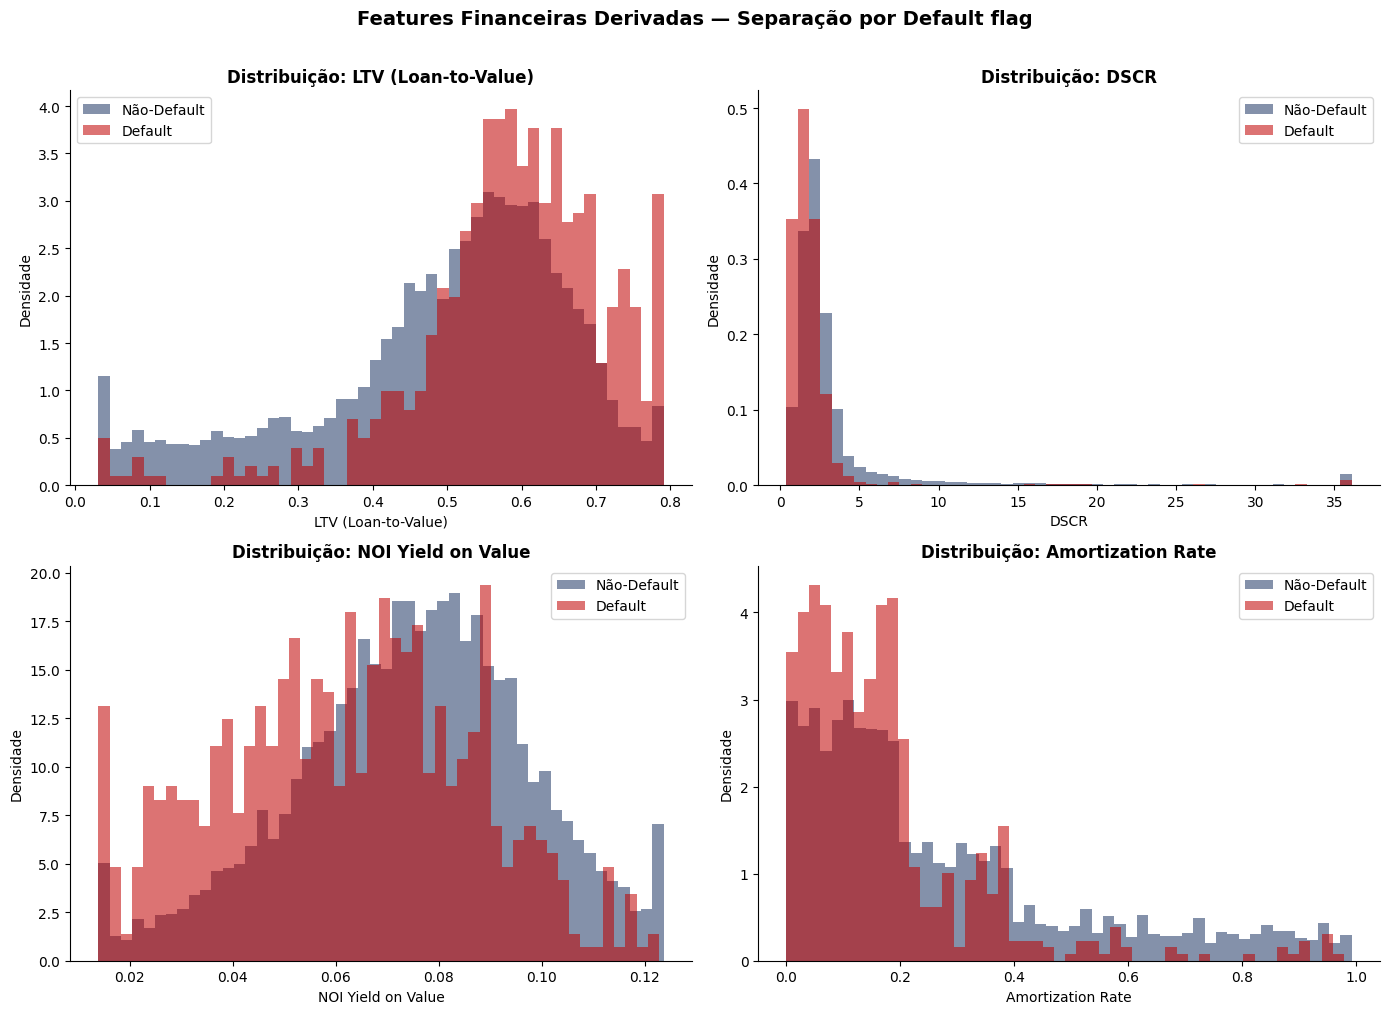

In [31]:
# =============================================================================
# Visualizar as 4 features financeiras mais importantes por Default flag
# Confirma visualmente que as features derivadas separam bem os grupos
# =============================================================================

target_col = 'default_flag'
features_to_plot = ['ltv', 'dscr', 'noi_yield', 'amortization_rate']
labels = ['LTV (Loan-to-Value)', 'DSCR', 'NOI Yield on Value', 'Amortization Rate']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (feat, label) in enumerate(zip(features_to_plot, labels)):
    if feat not in df_features.columns:
        continue
    d0 = df_features.loc[df_features[target_col] == 0, feat]
    d1 = df_features.loc[df_features[target_col] == 1, feat]
    axes[i].hist(d0, bins=50, alpha=0.55, color='#1F3864', label='Não-Default', density=True)
    axes[i].hist(d1, bins=50, alpha=0.55, color='#C00000', label='Default',     density=True)
    axes[i].set_title(f'Distribuição: {label}', fontweight='bold')
    axes[i].set_xlabel(label)
    axes[i].set_ylabel('Densidade')
    axes[i].legend()
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

plt.suptitle('Features Financeiras Derivadas — Separação por Default flag', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
path = os.path.join(OUTPUT_DIR, 'derived_features_distribution.png')
plt.savefig(path, bbox_inches='tight', dpi=150)
print(f'Figura salva: {path}')
plt.show()

In [32]:
# =============================================================================
# Verificar default rate dentro dos grupos de flags de refinanciamento
# =============================================================================

print('Default Rate por Near Maturity Flag:')
print(df_features.groupby('near_maturity_flag')['default_flag'].agg(['mean','count']).rename(columns={'mean':'default_rate','count':'n'}).round(4))

print('\nDefault Rate por Balloon Risk:')
print(df_features.groupby('balloon_risk')['default_flag'].agg(['mean','count']).rename(columns={'mean':'default_rate','count':'n'}).round(4))

print('\nDefault Rate por Property Class Ordinal:')
print(df_features.groupby('property_class_ord')['default_flag'].agg(['mean','count']).rename(columns={'mean':'default_rate','count':'n'}).round(4))

Default Rate por Near Maturity Flag:
                    default_rate     n
near_maturity_flag                    
0                         0.0684  7705
1                         0.1085  1254

Default Rate por Balloon Risk:
              default_rate     n
balloon_risk                    
0                   0.0629  7214
1                   0.1198  1745

Default Rate por Property Class Ordinal:
                    default_rate     n
property_class_ord                    
0                         0.0634  6247
1                         0.1385   917
2                         0.1015   867
3                         0.0560   928


---
## 7. Exportação

In [33]:
# =============================================================================
# Exportar df_features
# Este arquivo é a entrada direta do Notebook 04 (Modelagem).
# =============================================================================

# Tratar possíveis NaN residuais nas features numéricas (imputação por mediana)
numeric_feats = df_features.select_dtypes(include=[np.number]).columns.tolist()
target_in_numeric = 'default_flag' in numeric_feats

for col in numeric_feats:
    if col == 'default_flag':
        continue  # Nunca imputar o target
    n_null = df_features[col].isnull().sum()
    if n_null > 0:
        med = df_features[col].median()
        df_features[col] = df_features[col].fillna(med)
        print(f'  Imputação por mediana: {col} ({n_null} valores) → {med:.4f}')

df_features.to_csv(FEATURES_DATA_PATH, index=False, encoding='utf-8')

print(f'\ndf_features exportado com sucesso.')
print(f'Caminho: {FEATURES_DATA_PATH}')
print(f'Shape: {df_features.shape}')
print(f'Colunas: {list(df_features.columns)}')


df_features exportado com sucesso.
Caminho: ../data/processed/df_features.csv
Shape: (8959, 20)
Colunas: ['interest_rate', 'contractual_term', 'months_to_maturity', 'annual_tenant_turnover', 'default_flag', 'is_partially_amortizing', 'is_office', 'property_class_ord', 'ltv', 'dscr', 'loan_age_months', 'amortization_rate', 'noi_yield', 'near_maturity_flag', 'balloon_risk', 'property_type_office_building', 'property_type_retail_space', 'region_northeast', 'region_south', 'region_west']


---
## 8. Sumário da Fase 3

| Feature | Fórmula | Justificativa de Negócio | Hipótese de Sinal |
|---------|---------|--------------------------|------------------|
| `ltv` | Balance / Property Value | Alavancagem; LTV > 1 indica perda garantida em execução | + (maior LTV → mais risco) |
| `dscr` | NOI / Debt Service Anual | DSCR < 1 indica que o imóvel não paga seus juros | - (maior DSCR → menos risco) |
| `loan_age_months` | Contractual Term - MTM | Maturidade do empréstimo | ambíguo |
| `amortization_rate` | 1 - Balance/Original | Histórico de pagamento do principal | - (mais amortizado → menos risco) |
| `noi_yield` | NOI / Property Value | Cap rate implícito do imóvel | - (maior yield → menos risco) |
| `near_maturity_flag` | MTM ≤ 12 (binário) | Refinancing risk iminente | + |
| `balloon_risk` | Partial & MTM ≤ 24 (binário) | Balloon payment iminente | + |
| `is_partially_amortizing` | Repayment type (binário) | Balloon payment no final do prazo | + |
| `is_office` | Property type (binário) | Indicador de classe de ativo | a verificar |
| `property_class_ord` | Ordinal 0-3 | Qualidade do imóvel Office | - (maior classe → menos risco) |
| Dummies Region/Type | OHE | Controle geográfico e de ativo | a verificar |

**Próxima fase:** `04_modeling.ipynb` — Modelagem Preditiva.